In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

# Load Dataset

In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


# Exploratory Data Analysis

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [5]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


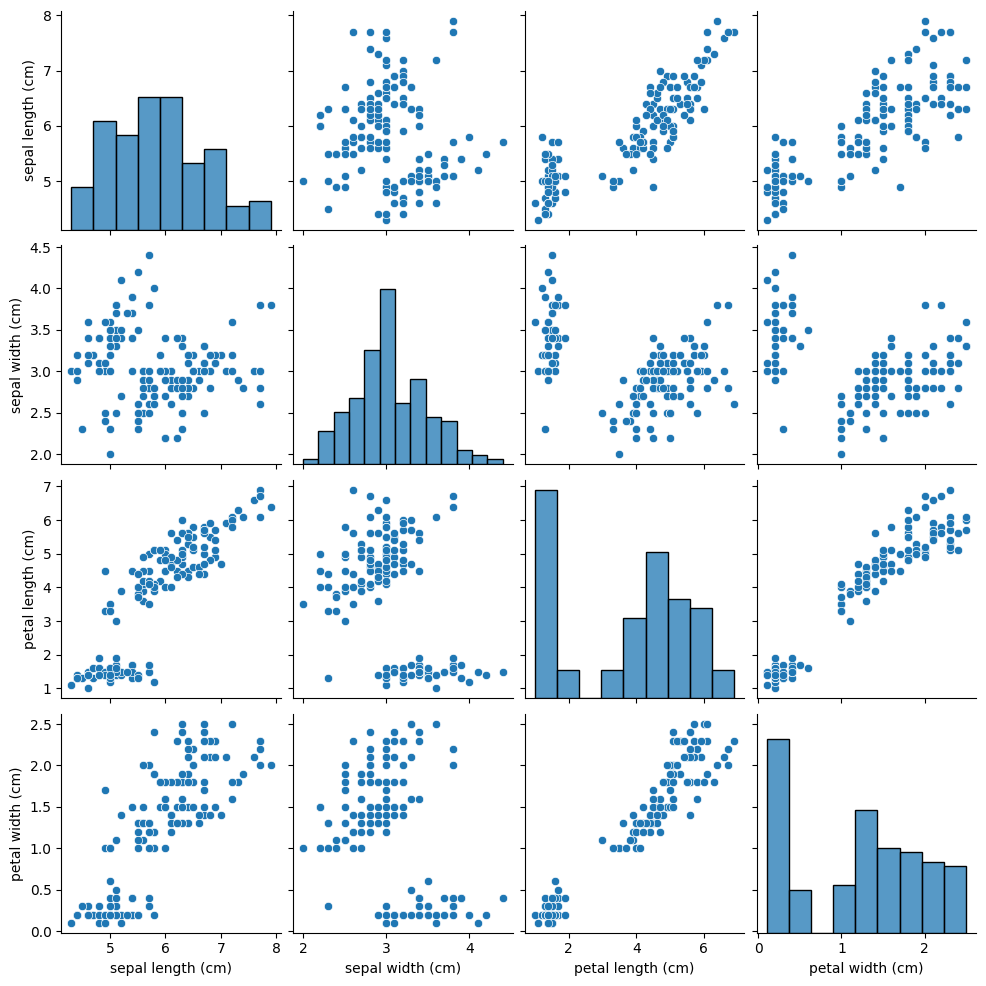

In [6]:
sns.pairplot(df)
plt.show()

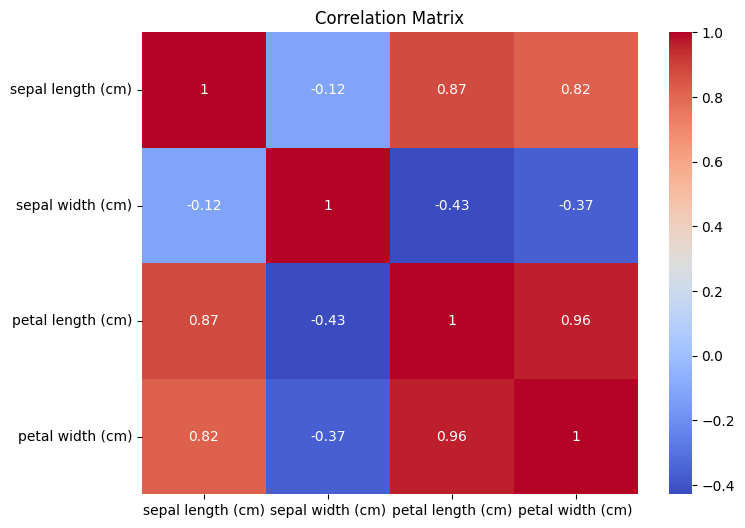

In [7]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

# Outlier Detection

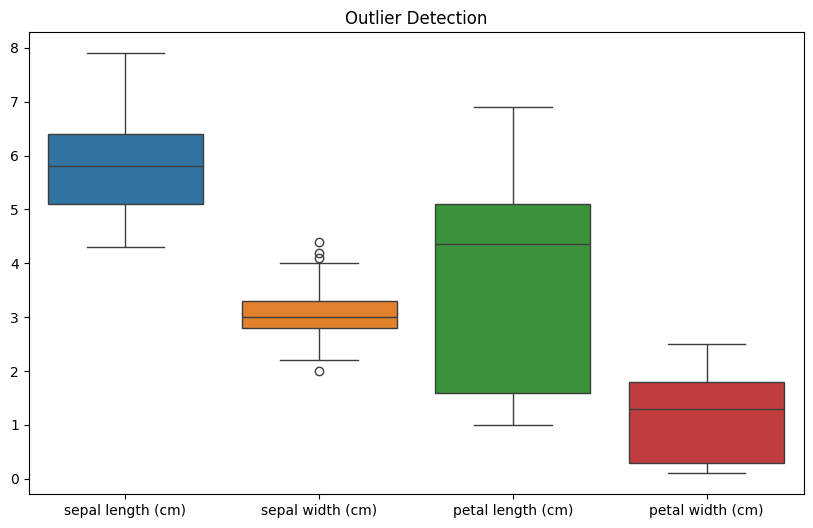

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df)

plt.title("Outlier Detection")
plt.show()

In [ ]:
# For this dataset, outliers are minimal and can be retained.

# Feature Scaling

In [9]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# K-Means Clustering

In [ ]:
# Elbow Method

In [10]:
wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

In [ ]:
# Plot Elbow Curve

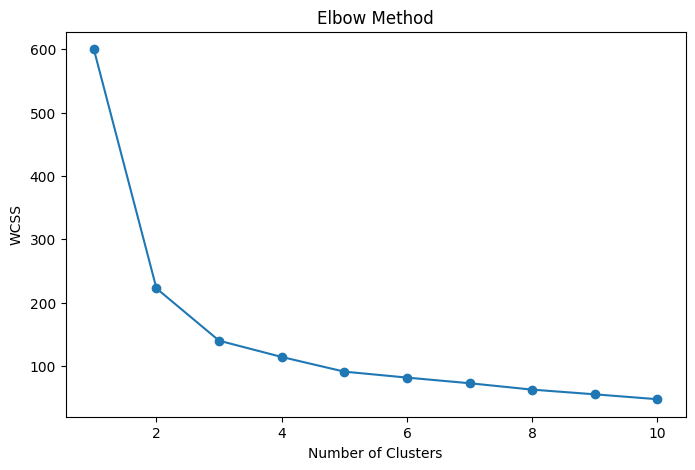

In [11]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

# Train Final K-Means Model

In [12]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

df["KMeans_Cluster"] = clusters

# Visualize K-Means Clusters

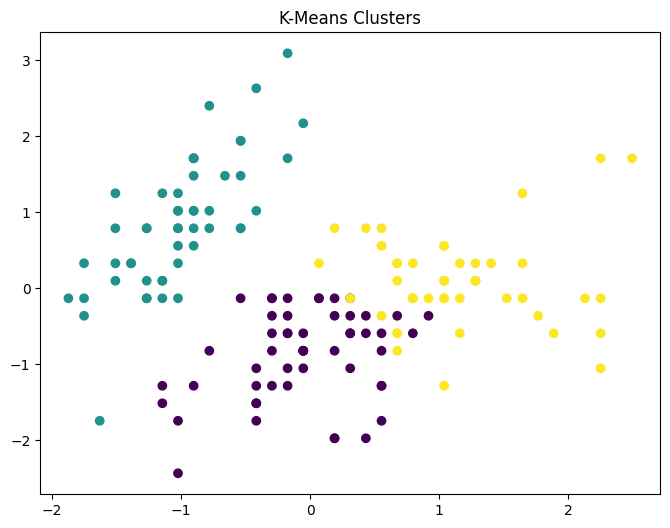

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=clusters
)

plt.title("K-Means Clusters")
plt.show()

# Silhouette Score

In [14]:
score = silhouette_score(
    scaled_data,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.45994823920518646


# Hierarchical Clustering

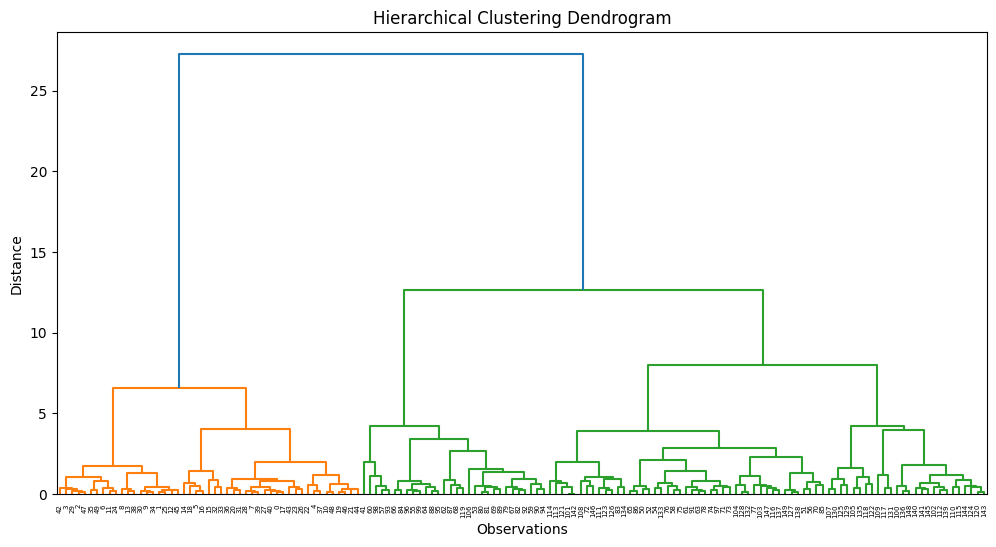

In [15]:
plt.figure(figsize=(12,6))

linked = linkage(
    scaled_data,
    method='ward'
)

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")

plt.show()

In [ ]:
# Train Hierarchical Model

In [17]:
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

hc_clusters = hc.fit_predict(scaled_data)

df["Hierarchical_Cluster"] = hc_clusters

# Visualize Hierarchical Clusters

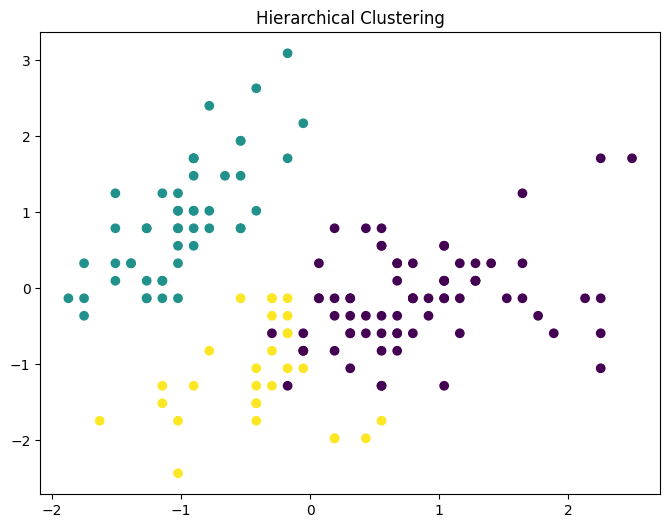

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=hc_clusters
)

plt.title("Hierarchical Clustering")
plt.show()

# Experiment with Linkage Methods

In [19]:
for method in ['ward','complete','average','single']:

    model = AgglomerativeClustering(
        n_clusters=3,
        linkage=method
    )

    labels = model.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    print(method, ":", score)

ward : 0.446689041028591
complete : 0.44961848359884726
average : 0.4802669329728697
single : 0.504645610832545


In [ ]:
# The Elbow Method suggested that 3 clusters were optimal.The silhouette score indicated good cluster separation.
The dendrogram showed natural grouping structures within the dataset.Ward linkage produced the most balanced clusters

In [ ]:
The dataset was successfully clustered using both K-Means and Hierarchical Clustering techniques. 
The Elbow Method and dendrogram analysis indicated that three clusters were appropriate. K-Means provided efficient and well-separated clusters, while Hierarchical Clustering offered additional insights into the relationships between observations. Overall, 
both methods effectively identified meaningful patterns within the data, with Ward linkage producing the most interpretable hierarchical clusters.